In [8]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt

from pic0lib.ndt_acquisition import UltrasonicAcquisition, load_h5

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
f = load_h5("example_data/calibration_block_5steps_1018steel.h5")

In [10]:
for x in f:
    pass
x

UltrasonicAcquisition(signal=array([-0.00195312, -0.00195312,  0.00195312, ...,  0.0078125 ,
        0.00585938,  0.00585938], shape=(8000,), dtype=float32), Fech=60000000.0, pon=95, poff=95, damp=6000, gain=50.0, target='Calibration 1018 steel block, ~25.0mm', timestamp='2026-05-16T15:40:46', h5_path='example_data/calibration_block_5steps_1018steel.h5', piezo_id='Pink 5MHz', piezo_central_freq=5000000.0, piezo_bandwidth=2000000.0)

8000


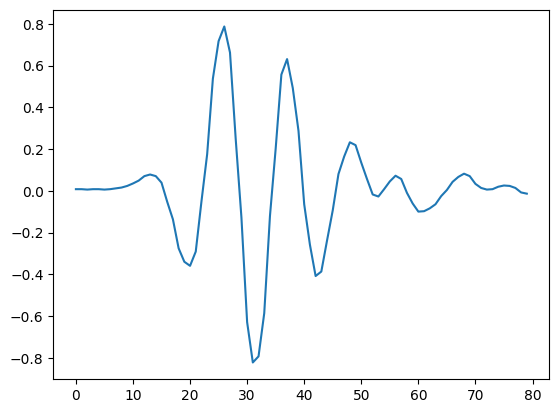

In [11]:
sgn = x.signal
pulse = x.signal[1975:1975+80]
print(len(x.signal))
plt.plot(pulse)

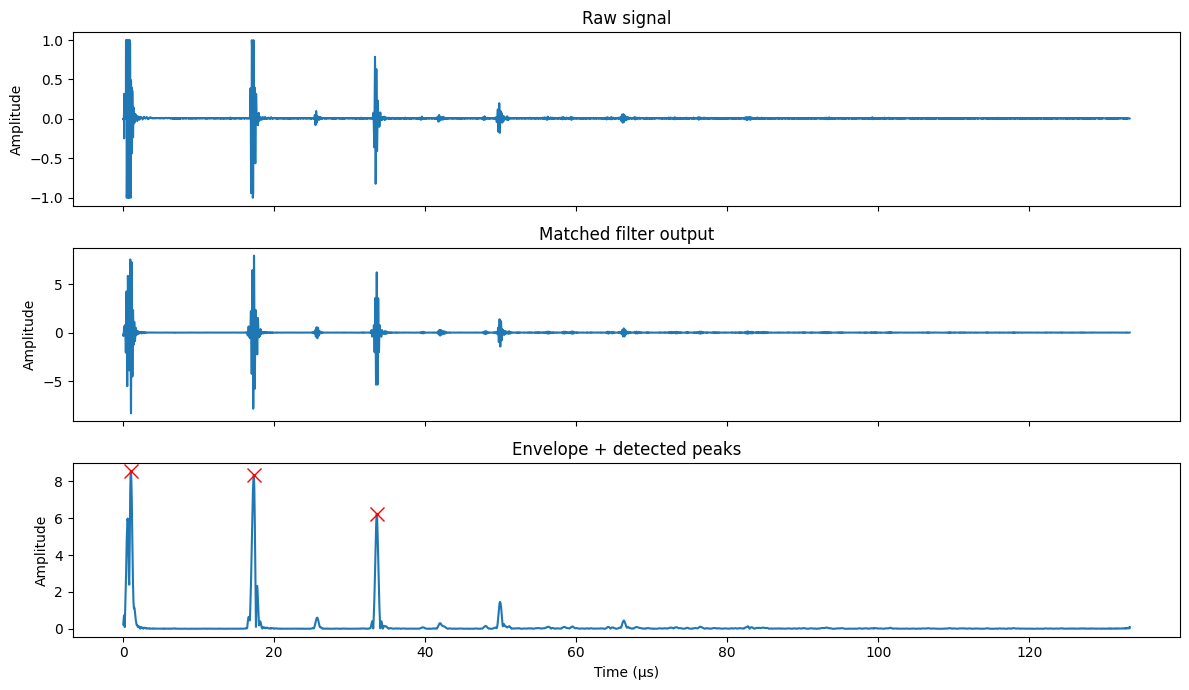

Peaks found at: [ 1.         17.28333333 33.58333333] µs


In [12]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# ── Your data ────────────────────────────────────────────────────────────
pulse = np.array(pulse)   # shape (75,)   – your known reference pulse
sig   = np.array(sgn)   # shape (8000,) – received signal
fs    = 60e6            # your sampling frequency in Hz (adjust!)

# ── 1. MATCHED FILTER (cross-correlation) ────────────────────────────────
# correlate(sig, pulse)  →  slides pulse over sig and computes dot-product
# mode='same'  →  output is same length as sig (8000 pts), easiest to work with
# method='fft' →  O(n log n), much faster than direct for long signals
matched = signal.correlate(sig, pulse, mode='same', method='fft')
A = matched
# ── 2. ENVELOPE via Hilbert transform ────────────────────────────────────
# hilbert() returns the analytic signal; abs() gives the instantaneous amplitude
envelope = np.abs(signal.hilbert(matched))

# ── 3. PEAK DETECTION ────────────────────────────────────────────────────
peaks, props = signal.find_peaks(
    envelope,
    height=0.3 * envelope.max(),   # ignore anything below 30% of max
    distance=int(0.5e-6 * fs),     # min separation between echoes (0.5 µs here)
    prominence=0.1 * envelope.max()
)

# Convert sample indices → time-of-flight
tof = peaks / fs   # seconds

# ── 4. QUICK PLOT ─────────────────────────────────────────────────────────
t = np.arange(len(sig)) / fs * 1e6   # time axis in µs

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(t, sig);                  axes[0].set_title("Raw signal")
axes[1].plot(t, matched);              axes[1].set_title("Matched filter output")
axes[2].plot(t, envelope)
axes[2].plot(peaks / fs * 1e6, envelope[peaks], "x", color="red", ms=10)
axes[2].set_title("Envelope + detected peaks")
axes[2].set_xlabel("Time (µs)")

for ax in axes:
    ax.set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

print(f"Peaks found at: {tof * 1e6} µs")

Text(0.5, 0, 'Lag (µs)')

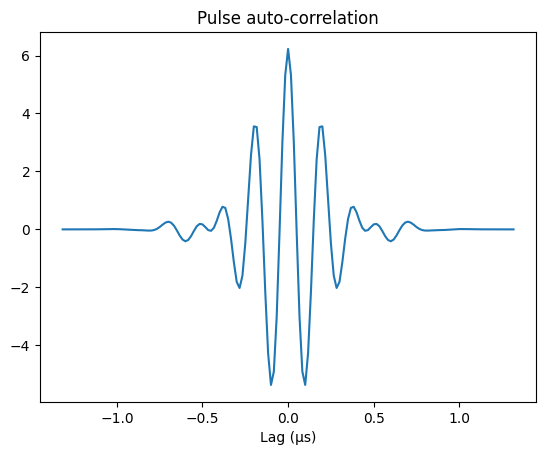

In [13]:
# Auto-correlate the pulse → gives its characteristic width / side-lobe level
autocorr = signal.correlate(pulse, pulse, mode='full', method='fft')
lags = signal.correlation_lags(len(pulse), len(pulse), mode='full')
lag_time = lags / fs * 1e6   # µs

plt.plot(lag_time, autocorr)
plt.title("Pulse auto-correlation")
plt.xlabel("Lag (µs)")

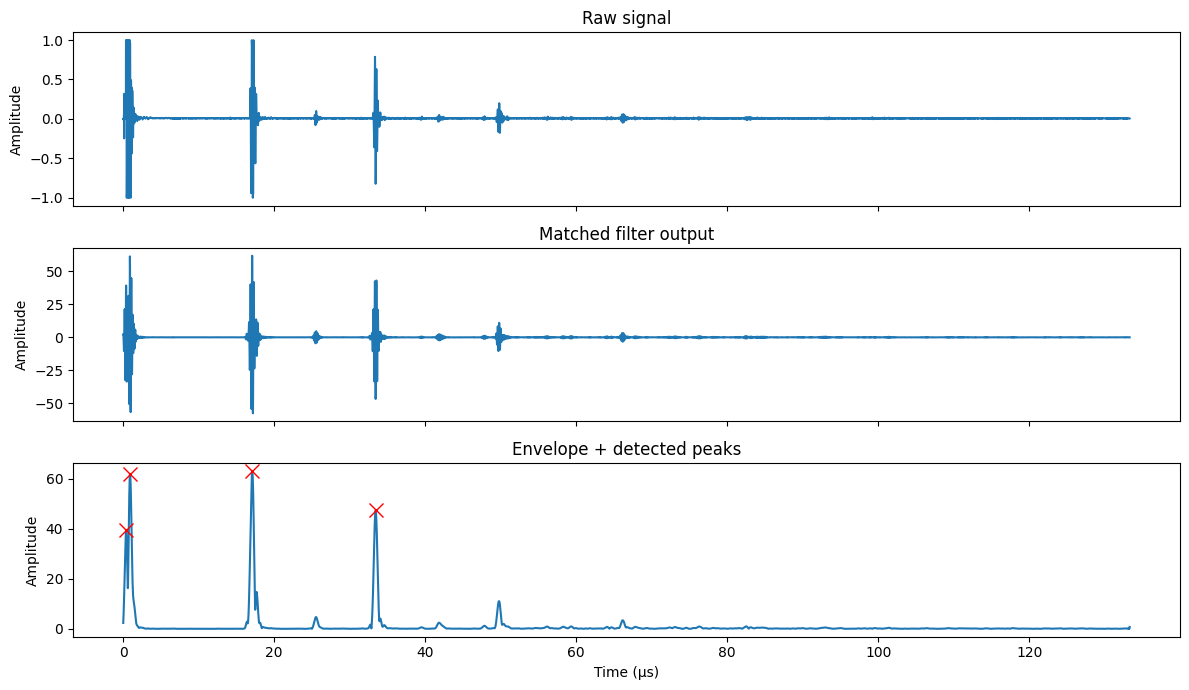

Peaks found at: [ 0.38333333  0.9        17.1        33.43333333] µs


In [14]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# ── Your data ────────────────────────────────────────────────────────────
pulse = np.array(autocorr)   # shape (75,)   – your known reference pulse
sig   = np.array(sgn)   # shape (8000,) – received signal
fs    = 60e6            # your sampling frequency in Hz (adjust!)

# ── 1. MATCHED FILTER (cross-correlation) ────────────────────────────────
# correlate(sig, pulse)  →  slides pulse over sig and computes dot-product
# mode='same'  →  output is same length as sig (8000 pts), easiest to work with
# method='fft' →  O(n log n), much faster than direct for long signals
matched = signal.correlate(sig, pulse, mode='same', method='fft')
B = matched
# ── 2. ENVELOPE via Hilbert transform ────────────────────────────────────
# hilbert() returns the analytic signal; abs() gives the instantaneous amplitude
envelope = np.abs(signal.hilbert(matched))

# ── 3. PEAK DETECTION ────────────────────────────────────────────────────
peaks, props = signal.find_peaks(
    envelope,
    height=0.3 * envelope.max(),   # ignore anything below 30% of max
    distance=int(0.5e-6 * fs),     # min separation between echoes (0.5 µs here)
    prominence=0.1 * envelope.max()
)

# Convert sample indices → time-of-flight
tof = peaks / fs   # seconds

# ── 4. QUICK PLOT ─────────────────────────────────────────────────────────
t = np.arange(len(sig)) / fs * 1e6   # time axis in µs

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(t, sig);                  axes[0].set_title("Raw signal")
axes[1].plot(t, matched);              axes[1].set_title("Matched filter output")
axes[2].plot(t, envelope)
axes[2].plot(peaks / fs * 1e6, envelope[peaks], "x", color="red", ms=10)
axes[2].set_title("Envelope + detected peaks")
axes[2].set_xlabel("Time (µs)")

for ax in axes:
    ax.set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

print(f"Peaks found at: {tof * 1e6} µs")

(950.0, 1150.0)

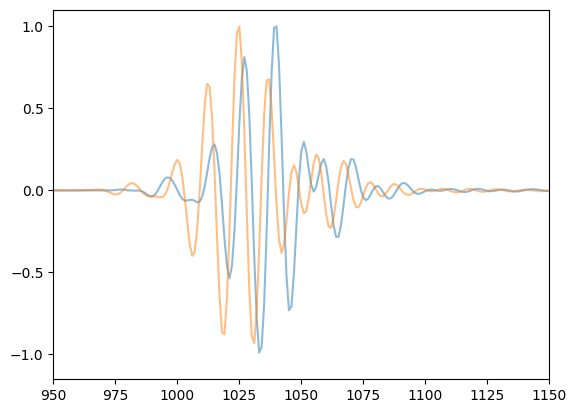

In [21]:
plt.plot(A/np.max(A), alpha=0.5)
plt.plot(B/np.max(B), alpha=0.5)
plt.xlim(950,1150)